In [1]:
# Let's import pandas data reader library in addition to other required libraries
# Let's import yfinance library to use the data

import numpy as np
import pandas as pd
import pandas_datareader as pdr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime
import yfinance as yf

In [2]:
# Let's use the data of Tesla stocks using yfinance library 

start_date = datetime(2020, 1, 1)
end_date = datetime(2024, 12, 31)
#df_tsla = pdr.get_data_yahoo('TSLA')
df_tsla = yf.download('TSLA', start='2020-01-01', end='2024-12-31')
df_tsla.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


<Axes: xlabel='Date'>

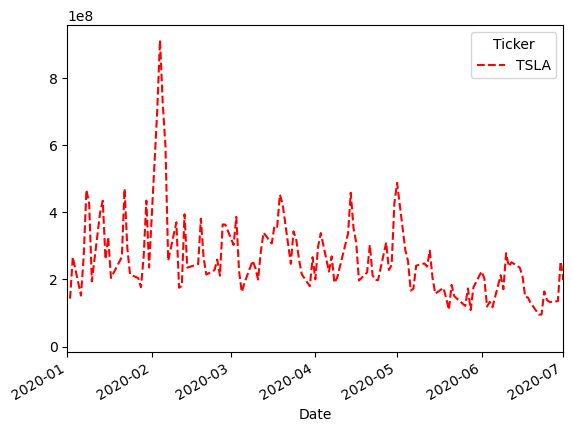

In [3]:
# We can plot the 'Volume' column in simple plot()
# We can also pass the arguments such as 'xlim' & 'ylim' if we want to zoom the data particularly on the dates passed.
# Remember, the xlim/ylim can be passed as a list or tuple. It must have start & end range.
df_tsla['Volume'].plot(xlim=['2020-01-01','2020-07-01'], c='red', ls='--')

In [4]:
df_tsla.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500


In [5]:
# I store the index of the df_tsla which is the date in a variable called 'tsla_index'
# I also store the date range using the location index in a variable called 'open_share'
# I do this because I want to plot some graph using dates.

tsla_index = df_tsla.index
open_share = df_tsla.loc['2020-01-02':'2020-07-01'] ['Open']

In [6]:
tsla_index

DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2024-12-16', '2024-12-17', '2024-12-18', '2024-12-19',
               '2024-12-20', '2024-12-23', '2024-12-24', '2024-12-26',
               '2024-12-27', '2024-12-30'],
              dtype='datetime64[ns]', name='Date', length=1257, freq=None)

In [7]:
open_share

Ticker,TSLA
Date,
2020-01-02,28.299999
2020-01-03,29.366667
2020-01-06,29.364668
2020-01-07,30.760000
2020-01-08,31.580000
...,...
2020-06-25,63.618000
2020-06-26,66.318665
2020-06-29,64.600670


In [8]:
# To check the datatype we will need to reset the index so that the index(Date) will be added as a new column.

df_tsla = df_tsla.reset_index()

In [9]:
# Now we will check the datatype of 'Date' column. It is now in datetime64[ns] format.
# Usually, it will be in object format. At that time, we need to modify the datatype using pd.to_datetime(df_tsla['Date'])
# If it is in datetime64[ns] format, we can ignore the conversion.
df_tsla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   (Date, )        1257 non-null   datetime64[ns]
 1   (Close, TSLA)   1257 non-null   float64       
 2   (High, TSLA)    1257 non-null   float64       
 3   (Low, TSLA)     1257 non-null   float64       
 4   (Open, TSLA)    1257 non-null   float64       
 5   (Volume, TSLA)  1257 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 59.1 KB


In [10]:
df_tsla['Volume'].expanding(min_periods=3, method='single').max()

Ticker,TSLA
0,NaN
1,NaN
2,266677500.0
3,268231500.0
4,467164500.0
...,...
1252,914082000.0
1253,914082000.0
1254,914082000.0
1255,914082000.0


In [11]:
df_tsla.set_index('Date', inplace=True)

## Resampling

Resampling in pandas means changing the frequency of your time series data:

Upsampling: increasing the frequency (e.g., from days to hours)

Downsampling: reducing the frequency (e.g., from days to months)

It is typically used with DateTimeIndex or PeriodIndex

**Syntax of resampling**

DataFrame.resample(rule, how=None, axis=0, fill_method=None, closed=None, label=None, convention='start')

**But usually combined with aggregation like:**

df.resample('M').sum()

**Common Resampling rules (frequency strings)**
 | Code        | Meaning      |
|-------------|--------------|
| `'D'`       | Day          |
| `'W'`       | Week         |
| `'M'`       | Month End    |
| `'MS'`      | Month Start  |
| `'Q'`       | Quarter End  |
| `'H'`       | Hour         |
| `'T'` or `'min'` | Minute  |
| `'S'`       | Second       |
| `'Y'`       | Year End     |
    End     |

**More examples in resample()**

More Options in resample()

label: Places the label on the left or right bin (default 'right')

closed: Whether the interval is closed on the left or right ('right', 'left')

on: Use a column (instead of index) for date
time-based re

| Operation   | Syntax Example                           |
|-------------|-------------------------------------------|
| Downsample  | `df.resample('M').sum()`                  |
| Upsample    | `df.resample('H').ffill()`                |
| Fill NaNs   | `.ffill()`, `.bfill()`, `.fillna()`       |
| Use column  | `df.resample('M', on='date')`        

</div>
f.resample('M', on='dat
e')
**You can also refer below link for detailed information** Year End


**https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78/**

In [43]:
# Let's now use the resample rule of 'YE' which is 'Year End' frequency. We can also use 'A' but it is deprecated
# Every year what is the minimum -->High, Low, Open, Close, Volume Adj Close columns. It gives the minimum value of all columns
df_tsla.resample(rule='YE').min()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-12-31,24.081333,26.990667,23.367332,24.980000,52073100
2021-12-31,187.666672,188.736664,179.830002,184.183334,29401800
2022-12-31,109.099998,116.269997,108.239998,110.349998,41864700
2023-12-31,108.099998,111.750000,101.809998,103.000000,65125200
2024-12-31,142.050003,144.440002,138.800003,140.559998,37167600


In [33]:
# Let's use the same rule for max aggrigate()
df_tsla.resample(rule='YE').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-12-31,235.223328,239.573334,230.373337,233.330002,914082000
2021-12-31,409.970001,414.496674,405.666656,411.470001,268189500
2022-12-31,399.926666,402.666656,378.679993,396.516663,221923300
2023-12-31,293.339996,299.290009,289.519989,296.040009,306590600
2024-12-31,479.859985,488.540009,457.510010,475.899994,243869700


<Axes: xlabel='Date'>

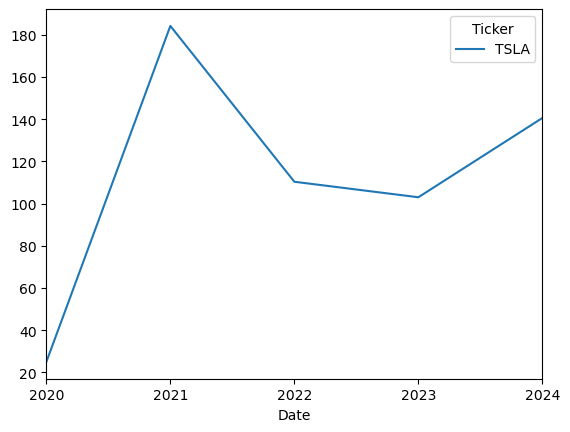

In [39]:
# Now let's plot the 'Open' column for the 'YE' rule using min aggregate()
df_tsla.resample(rule='YE').min()['Open'].plot()

# We can use below code as well which gives the same output.
# df_tsla['Open'].resample(rule='YE').min().plot()

<Axes: xlabel='Date'>

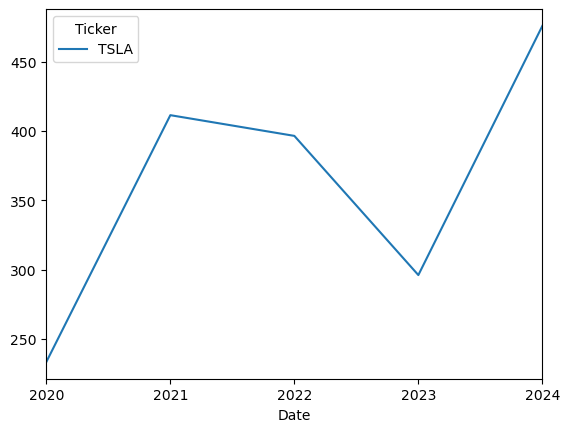

In [41]:
# Now let's plot the 'Open' column for the 'YE' rule using max aggregate()
df_tsla.resample(rule='YE').max()['Open'].plot()

In [45]:
# Let's now do 'quarterly start' frequency and the rule is 'QS' using max aggregate().
df_tsla.resample(rule='QS').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-01,61.161331,64.599335,60.068001,61.566666,914082000
2020-04-01,71.987335,72.512665,66.915337,67.518669,487977000
2020-07-01,166.106674,167.496674,156.836670,167.380005,584781000
2020-10-01,235.223328,239.573334,230.373337,233.330002,666378600
2021-01-01,294.363342,300.133331,290.533325,297.126678,268189500
2021-04-01,254.106674,260.263336,244.203339,256.899994,147052200
2021-07-01,263.786682,266.333344,258.333344,262.399994,100847400
2021-10-01,409.970001,414.496674,405.666656,411.470001,188556300


<Axes: xlabel='Date'>

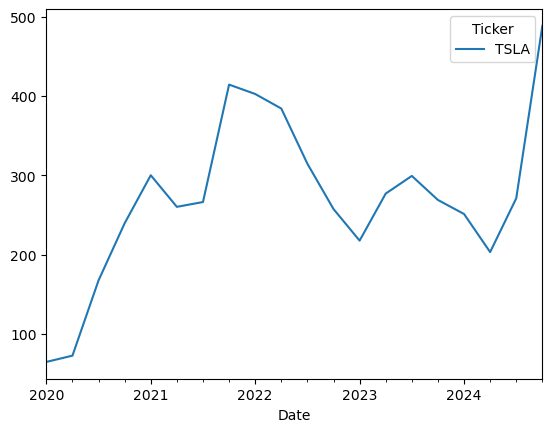

In [49]:
# Let's now plot the 'High' column for 'quarterly start' using max aggregate()
df_tsla.resample(rule='QS').max()['High'].plot()

In [55]:
# Let's now see the 'business year end' frequency and the rule is 'BYE' using max aggregate()
# You can also use rule as 'BA'. But it is deprecated.
df_tsla.resample(rule='BYE').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-12-31,235.223328,239.573334,230.373337,233.330002,914082000
2021-12-31,409.970001,414.496674,405.666656,411.470001,268189500
2022-12-30,399.926666,402.666656,378.679993,396.516663,221923300
2023-12-29,293.339996,299.290009,289.519989,296.040009,306590600
2024-12-31,479.859985,488.540009,457.510010,475.899994,243869700


In [57]:
# Let's now see the 'business quarters' frequency and the rule is 'BQS' using max aggregate()
df_tsla.resample(rule='BQS').max()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-01,61.161331,64.599335,60.068001,61.566666,914082000
2020-04-01,71.987335,72.512665,66.915337,67.518669,487977000
2020-07-01,166.106674,167.496674,156.836670,167.380005,584781000
2020-10-01,235.223328,239.573334,230.373337,233.330002,666378600
2021-01-01,294.363342,300.133331,290.533325,297.126678,268189500
2021-04-01,254.106674,260.263336,244.203339,256.899994,147052200
2021-07-01,263.786682,266.333344,258.333344,262.399994,100847400
2021-10-01,409.970001,414.496674,405.666656,411.470001,188556300


<Axes: xlabel='Date'>

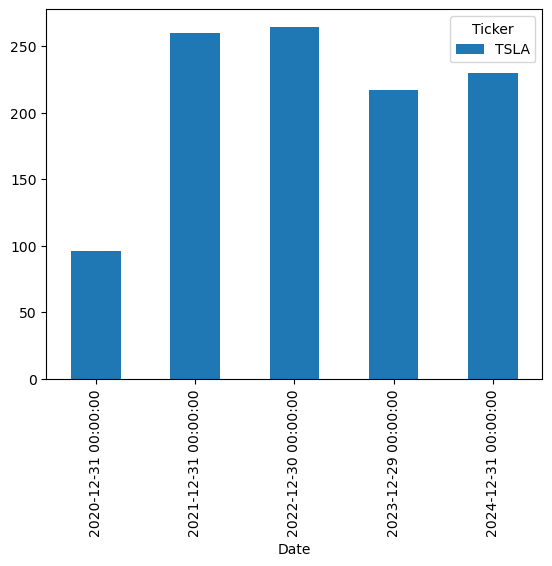

In [61]:
# Let's now plot the 'business year end' frequency and the rule is 'BYE' for 'Open' column using mean aggregate()
df_tsla['Open'].resample(rule='BYE').mean().plot(kind='bar')

In [69]:
# Let's now see the 'monthly or month end' frequency and the rule is 'ME' for 'Open' column using mean aggregate()
# We can also use the rule 'M' but that is deprecated.
df_tsla['Open'].resample(rule='ME').mean()

Ticker,TSLA
Date,
2020-01-31,34.869683
2020-02-29,52.983614
2020-03-31,37.595031
2020-04-30,44.352985
2020-05-31,53.270667
2020-06-30,63.879576
2020-07-31,97.662666
2020-08-31,118.170762
2020-09-30,138.094286


<Axes: xlabel='Date'>

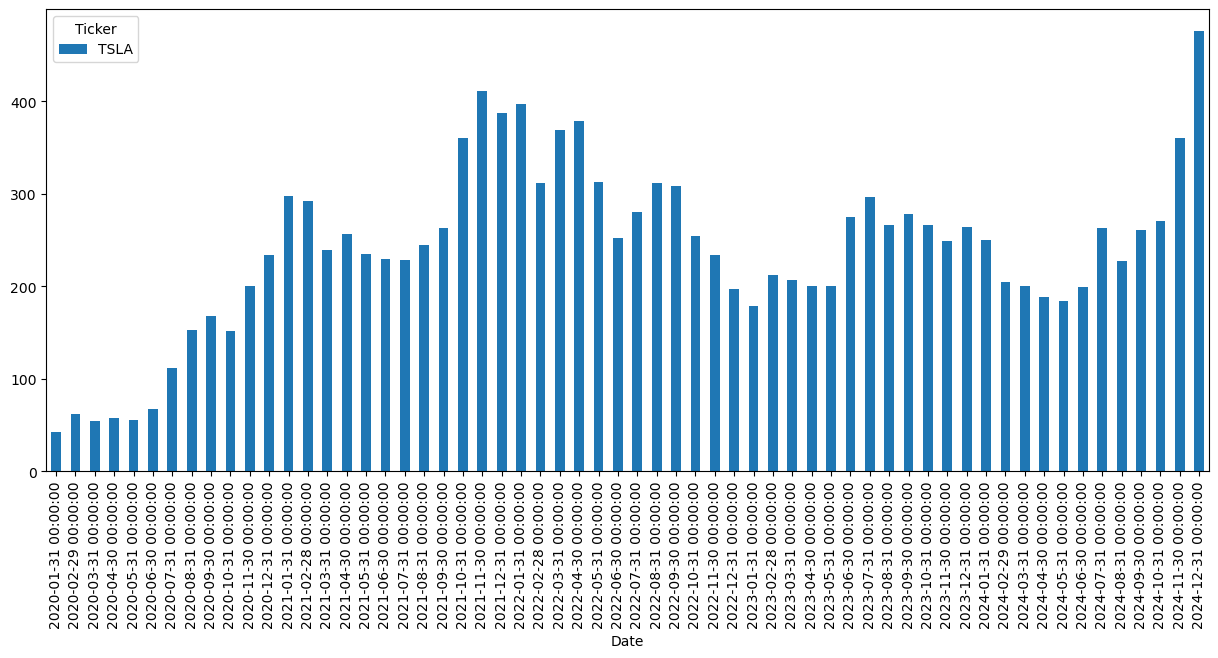

In [79]:
# Let's now plot the 'monthly or month end' frequency and the rule is 'ME' for 'Open' column using max aggregate()
df_tsla['Open'].resample(rule='ME').max().plot(kind='bar', figsize=(15,6))

In [91]:
# Let's now see the rolling() with respect to 'Open' column.
df_tsla['Open'].rolling(window=3).mean()

Ticker,TSLA
Date,
2020-01-02,NaN
2020-01-03,NaN
2020-01-06,29.010445
2020-01-07,29.830445
2020-01-08,30.568223
...,...
2024-12-23,436.130005
2024-12-24,430.803335
2024-12-26,444.019999
